# Predicción de Precios Inmobiliarios usando Regresión Lineal Múltiple

## 🏠 Objetivo de Negocio

En este notebook desarrollaremos un modelo de **Regresión Lineal Múltiple** para predecir precios de propiedades inmobiliarias, complementando el análisis realizado con Árbol de Decisión.

### ¿Por qué Regresión Lineal?

* **Interpretabilidad máxima**: Cada coeficiente indica el impacto exacto en USD de cada variable
* **Velocidad**: Entrenamiento y predicción muy rápidos
* **Baseline**: Modelo estándar para comparar con algoritmos más complejos
* **Estadísticamente fundamentado**: Intervalos de confianza, p-valores, R²

### Caso de uso

La misma agencia inmobiliaria quiere:
1. Comparar Regresión Lineal vs Árbol de Decisión
2. Entender el impacto **lineal** de cada característica en el precio
3. Identificar si la relación precio-features es predominantemente lineal
4. Obtener un modelo simple y rápido para estimaciones rápidas

**Diferencia clave**: Mientras el Árbol de Decisión captura relaciones no lineales, la Regresión Lineal asume que el efecto de cada variable es **constante** y **aditivo**.

## 📊 ¿Qué es la Regresión Lineal Múltiple?

### Concepto

La **Regresión Lineal Múltiple** modela la relación entre una variable objetivo (precio) y múltiples variables predictoras usando una ecuación lineal:

```
Precio = β0 + β1×área + β2×habitaciones + β3×baños + ... + error
```

* **β0 (intercepto)**: Precio base cuando todas las variables son 0
* **β1, β2, β3...**: Coeficientes que indican el cambio en precio por cada unidad de cambio en la variable
* **error**: Variabilidad no explicada por el modelo

### Diferencias con Árbol de Decisión:

| Aspecto | Regresión Lineal | Árbol de Decisión |
|---------|-------------------|----------------------|
| **Relación** | Lineal (constante) | No lineal (segmentada) |
| **Interpretación** | Coeficientes directos | Importancia de features |
| **Supuestos** | Linealidad, normalidad | Ninguno |
| **Extrapolación** | Mejor | Pobre |
| **Interacciones** | Requiere crearlas manualmente | Las detecta automáticamente |
| **Overfitting** | Menos propenso | Más propenso |

### ¿Cuándo usar Regresión Lineal?

✅ **Ventajas:**
* **Muy rápida**: Entrenamiento y predicción instantáneos
* **Interpretable**: "Cada m² adicional aumenta el precio en $2,000"
* **Estadísticamente robusta**: P-valores, intervalos de confianza
* **Menos propenso a overfitting**: Especialmente con pocas features
* **Extrapola mejor**: Puede predecir fuera del rango de entrenamiento

⚠️ **Limitaciones:**
* **Asume linealidad**: No captura efectos no lineales ("piscina solo vale en casas grandes")
* **Requiere normalización**: Variables en diferentes escalas afectan coeficientes
* **Sensible a multicolinealidad**: Variables correlacionadas causan inestabilidad
* **Sensible a outliers**: Valores extremos sesgan la línea de regresión

### Supuestos críticos:

1. **Linealidad**: La relación entre X e Y es lineal
2. **Independencia**: Los errores son independientes
3. **Homocedasticidad**: Varianza constante de errores
4. **Normalidad**: Los errores siguen distribución normal
5. **No multicolinealidad**: Las variables predictoras no están altamente correlacionadas

In [0]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

# PySpark ML - Framework de Machine Learning
from pyspark.ml.regression import LinearRegression  # Regresión Lineal
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler  # Preparación de datos
from pyspark.ml.evaluation import RegressionEvaluator  # Evaluación
from pyspark.ml import Pipeline  # Pipeline de transformaciones

# PySpark SQL
from pyspark.sql import functions as F
from pyspark.sql.types import *

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías importadas correctamente")
print("💡 Nota: Regresión Lineal requiere normalización (StandardScaler)")

✅ Librerías importadas correctamente
💡 Nota: Regresión Lineal requiere normalización (StandardScaler)


## 📊 Dataset: Mismo que Árbol de Decisión

Utilizaremos el **mismo dataset de propiedades inmobiliarias** que en el notebook anterior para poder **comparar** ambos modelos directamente.

### Variables:
* **Features numéricas**: area_m2, habitaciones, baños, antiguedad_anos, distancia_centro_km, piso, garaje, piscina
* **Feature categórica**: barrio
* **Target**: precio_venta (USD)

### Ventaja de comparación:
Usando los mismos datos, podemos evaluar:
* ¿Cuál modelo tiene menor error (RMSE, MAE)?
* ¿Cuál explica mejor la varianza (R²)?
* ¿La relación precio-features es más lineal o no lineal?

In [0]:
# =============================================================================
# CREACIÓN DEL DATASET (MISMO QUE ÁRBOL DE DECISIÓN)
# =============================================================================

np.random.seed(42)
n_propiedades = 10000

def generar_precio(area, habitaciones, banos, antiguedad, distancia, piso, garaje, piscina, barrio):
    precio_base = area * 2000
    precio_base += habitaciones * 15000
    precio_base += banos * 10000
    precio_base -= antiguedad * 1500
    precio_base -= distancia * 3000
    precio_base += piso * 2000 if piso > 0 else 5000
    precio_base += 25000 if garaje == 1 else 0
    precio_base += 40000 if piscina == 1 else 0
    multiplicador_barrio = {"Centro": 1.3, "Norte": 1.15, "Este": 1.0, "Sur": 0.9, "Oeste": 0.95}
    precio_base *= multiplicador_barrio.get(barrio, 1.0)
    ruido = np.random.uniform(0.9, 1.1)
    precio_final = precio_base * ruido
    return max(100000, min(800000, precio_final))

data = []
for i in range(n_propiedades):
    area = int(np.random.gamma(9, 15))
    area = max(50, min(300, area))
    habitaciones = int(np.random.choice([1, 2, 3, 4, 5], p=[0.1, 0.25, 0.35, 0.2, 0.1]))
    banos = int(np.random.choice([1, 2, 3, 4], p=[0.2, 0.45, 0.25, 0.1]))
    antiguedad = int(np.random.exponential(12))
    antiguedad = min(50, antiguedad)
    distancia = round(np.random.uniform(0, 20), 2)
    piso = int(np.random.choice([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], p=[0.3, 0.15, 0.12, 0.1, 0.08, 0.07, 0.06, 0.05, 0.04, 0.02, 0.01]))
    garaje = int(np.random.choice([0, 1], p=[0.3, 0.7]))
    piscina = int(np.random.choice([0, 1], p=[0.85, 0.15]))
    barrio = np.random.choice(["Centro", "Norte", "Sur", "Este", "Oeste"])
    precio = generar_precio(area, habitaciones, banos, antiguedad, distancia, piso, garaje, piscina, barrio)
    data.append((i, area, habitaciones, banos, antiguedad, distancia, piso, garaje, piscina, barrio, round(precio, 2)))

schema = StructType([
    StructField("propiedad_id", IntegerType(), False),
    StructField("area_m2", IntegerType(), True),
    StructField("habitaciones", IntegerType(), True),
    StructField("banos", IntegerType(), True),
    StructField("antiguedad_anos", IntegerType(), True),
    StructField("distancia_centro_km", DoubleType(), True),
    StructField("piso", IntegerType(), True),
    StructField("garaje", IntegerType(), True),
    StructField("piscina", IntegerType(), True),
    StructField("barrio", StringType(), True),
    StructField("precio_venta", DoubleType(), True)
])

df = spark.createDataFrame(data, schema)

print("=" * 80)
print("📋 DATASET CARGADO")
print("=" * 80)
print(f"Total de propiedades: {df.count()}")
df.select("area_m2", "habitaciones", "barrio", "precio_venta").show(5)
print("✅ Datos listos para Regresión Lineal")

📋 DATASET CARGADO
Total de propiedades: 10000
+-------+------------+------+------------+
|area_m2|habitaciones|barrio|precio_venta|
+-------+------------+------+------------+
|    153|           3| Oeste|   406900.03|
|    123|           2|   Sur|   259088.97|
|    119|           3|Centro|   417650.81|
|    122|           2|Centro|   331715.52|
|     81|           3|  Este|   136356.82|
+-------+------------+------+------------+
only showing top 5 rows
✅ Datos listos para Regresión Lineal


## 🔧 Preparación de Datos con Normalización

### ¿Por qué normalizar en Regresión Lineal?

**Diferencia crítica con Árbol de Decisión:**
* **Árboles**: NO requieren normalización (invariante a escala)
* **Regresión Lineal**: SÍ requiere normalización

### Problema sin normalizar:

Si tenemos:
* `area_m2`: rango 50-300
* `distancia_centro_km`: rango 0-20

Sin normalizar, el algoritmo daría más peso a `area_m2` simplemente porque tiene valores más grandes, NO porque sea más importante.

### StandardScaler:

Transforma cada variable a:
```
valor_normalizado = (valor - media) / desviación_estándar
```

Resultado: Todas las variables tienen media=0 y desviación=1, equiparando su escala.

### Pasos:
1. Codificar variables categóricas
2. Vector Assembly
3. **StandardScaler** (nuevo vs árboles)
4. Train/test split

In [0]:
# =============================================================================
# PREPARACIÓN DE DATOS CON NORMALIZACIÓN
# =============================================================================

print("🔧 PREPARACIÓN DE DATOS PARA REGRESIÓN LINEAL")
print("=" * 50)

# 1. Codificar barrio
barrio_indexer = StringIndexer(inputCol="barrio", outputCol="barrio_idx")
df = barrio_indexer.fit(df).transform(df)

# 2. Features
feature_columns = [
    "area_m2", "habitaciones", "banos", "antiguedad_anos",
    "distancia_centro_km", "piso", "garaje", "piscina", "barrio_idx"
]

# 3. Vector Assembly
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features_raw")
df = assembler.transform(df)

# 4. Normalización con StandardScaler (CRÍTICO para Regresión Lineal)
print("\n⚠️  NORMALIZANDO FEATURES con StandardScaler...")
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,   # Dividir por desviación estándar
    withMean=True   # Restar la media
)

scaler_model = scaler.fit(df)
df_scaled = scaler_model.transform(df)

print("✅ Features normalizadas (media=0, std=1)")
print("   - Esto asegura que todas las variables tengan el mismo peso inicial")
print("   - Los coeficientes serán comparables entre sí\n")

# 5. Seleccionar columnas finales
df_final = df_scaled.select("propiedad_id", "features", F.col("precio_venta").alias("label"))

print("Dataset preparado:")
df_final.printSchema()
print("\n✅ Datos listos para Regresión Lineal")

🔧 PREPARACIÓN DE DATOS PARA REGRESIÓN LINEAL

⚠️  NORMALIZANDO FEATURES con StandardScaler...
✅ Features normalizadas (media=0, std=1)
   - Esto asegura que todas las variables tengan el mismo peso inicial
   - Los coeficientes serán comparables entre sí

Dataset preparado:
root
 |-- propiedad_id: integer (nullable = false)
 |-- features: vectorudt (nullable = true)
 |-- label: double (nullable = true)


✅ Datos listos para Regresión Lineal


## 📊 División Train/Test

Misma estrategia: 80% train / 20% test con seed=42 para comparar con Árbol de Decisión.

In [0]:
# Dividir datos
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"📈 Train: {train_data.count()} | Test: {test_data.count()}")
print("✅ División completada")

📈 Train: 8046 | Test: 1954
✅ División completada


## 📊 Entrenamiento: Regresión Lineal

### Hiperparámetros:

* **maxIter**: Número máximo de iteraciones (default: 100)
* **regParam**: Parámetro de regularización L2 (Ridge)
  * 0 = sin regularización
  * >0 = penaliza coeficientes grandes (evita overfitting)
* **elasticNetParam**: Balance entre L1 (Lasso) y L2 (Ridge)
  * 0 = Ridge (L2 puro)
  * 1 = Lasso (L1 puro)
  * 0.5 = Elastic Net (mezcla)

### Configuración:
* **regParam = 0.1**: Regularización leve
* **elasticNetParam = 0.0**: Ridge (L2) - reduce magnitud de coeficientes
* **maxIter = 100**: Suficiente para convergencia

In [0]:
# =============================================================================
# ENTRENAMIENTO: REGRESIÓN LINEAL
# =============================================================================

print("📊 ENTRENAMIENTO DE REGRESIÓN LINEAL")
print("=" * 50)

# Crear modelo
lr = LinearRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.1,          # Regularización L2 (Ridge)
    elasticNetParam=0.0    # 0 = Ridge puro
)

print("Hiperparámetros:")
print(f"  - Máximo iteraciones: {lr.getMaxIter()}")
print(f"  - Regularización (regParam): {lr.getRegParam()}")
print(f"  - ElasticNet (0=Ridge, 1=Lasso): {lr.getElasticNetParam()}")

# Entrenar
print("\n⏳ Entrenando modelo...")
model = lr.fit(train_data)
print("✅ Modelo entrenado\n")

# Información del modelo
print("📊 INFORMACIÓN DEL MODELO")
print("=" * 50)
print(f"Intercepto (β0): ${model.intercept:,.2f}")
print(f"Número de features: {len(model.coefficients)}")
print(f"\nEcuación del modelo:")
print(f"Precio = {model.intercept:.2f}")
for i, (feat, coef) in enumerate(zip(feature_columns, model.coefficients)):
    print(f"         + {coef:.2f} × {feat}")

print("\n✅ Modelo listo para predicciones")

📊 ENTRENAMIENTO DE REGRESIÓN LINEAL
Hiperparámetros:
  - Máximo iteraciones: 100
  - Regularización (regParam): 0.1
  - ElasticNet (0=Ridge, 1=Lasso): 0.0

⏳ Entrenando modelo...
✅ Modelo entrenado

📊 INFORMACIÓN DEL MODELO
Intercepto (β0): $337,707.08
Número de features: 9

Ecuación del modelo:
Precio = 337707.08
         + 93531.63 × area_m2
         + 18016.33 × habitaciones
         + 9779.57 × banos
         + -17508.99 × antiguedad_anos
         + -18736.94 × distancia_centro_km
         + 4359.05 × piso
         + 11029.15 × garaje
         + 15559.22 × piscina
         + 29118.85 × barrio_idx

✅ Modelo listo para predicciones


In [0]:
# =============================================================================
# EVALUACIÓN DEL MODELO
# =============================================================================

print("📈 EVALUACIÓN DEL MODELO")
print("=" * 70)

# Predicciones
predictions = model.transform(test_data)

# Ver ejemplos
print("Ejemplos de predicciones:")
predictions.select("propiedad_id", "label", "prediction").show(10)

# Evaluador
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction")

# Métricas
rmse = evaluator.setMetricName("rmse").evaluate(predictions)
mae = evaluator.setMetricName("mae").evaluate(predictions)
r2 = evaluator.setMetricName("r2").evaluate(predictions)

print("\n" + "=" * 70)
print("📈 MÉTRICAS DE REGRESIÓN LINEAL")
print("=" * 70)
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")
print(f"R²: {r2:.4f} ({r2*100:.2f}% de varianza explicada)")

predictions_pd = predictions.select("label", "prediction").toPandas()
error_pct = abs((predictions_pd['label'] - predictions_pd['prediction']) / predictions_pd['label']) * 100
print(f"Error Porcentual Promedio: {error_pct.mean():.2f}%")

print("\n✅ Evaluación completada")

📈 EVALUACIÓN DEL MODELO
Ejemplos de predicciones:
+------------+---------+------------------+
|propiedad_id|    label|        prediction|
+------------+---------+------------------+
|           2|417650.81|331884.51725887146|
|           6|403948.38| 408932.7413942173|
|           8|201893.95|252419.20588778553|
|          13|220556.74|221094.11406235117|
|          19|265721.05|277908.88789235166|
|          23|204865.44|219902.36963762838|
|          29|294284.01|  300757.614102626|
|          35|430361.61| 372535.6737627557|
|          45| 230011.7|299064.66620599694|
|          46|354925.56|399739.16792197106|
+------------+---------+------------------+
only showing top 10 rows

📈 MÉTRICAS DE REGRESIÓN LINEAL
RMSE: $43,214.81
MAE: $34,381.29
R²: 0.8505 (85.05% de varianza explicada)
Error Porcentual Promedio: 10.51%

✅ Evaluación completada


## 💡 Interpretación de Coeficientes

### ¿Qué significan los coeficientes?

Cada coeficiente (β) representa:
* **El cambio en el precio** (en USD) cuando esa variable **aumenta en 1 unidad**, manteniendo todas las demás constantes.

### Ejemplo:

Si el coeficiente de `area_m2` es **+2,000**:
* Cada metro cuadrado adicional **aumenta el precio en $2,000**
* Una casa de 150m² vale $300,000 más que una de 0m² (solo por área)

Si el coeficiente de `antiguedad_anos` es **-1,500**:
* Cada año adicional de antigüedad **reduce el precio en $1,500**
* Una casa de 20 años vale $30,000 menos que una nueva

### Signo de los coeficientes:

* **Positivo (+)**: La variable aumenta el precio (ej: área, baños, piscina)
* **Negativo (-)**: La variable reduce el precio (ej: antigüedad, distancia al centro)

### Magnitud:

* **Coeficiente grande** (ej: 5,000): Impacto fuerte en el precio
* **Coeficiente pequeño** (ej: 500): Impacto menor

### Limitación clave:

**Los coeficientes asumen efecto lineal y constante:**
* Regresión Lineal dice: "Cada m² vale siempre $2,000"
* Realidad: Tal vez los primeros 50m² valen más, y después el efecto disminuye

Esto es lo que los **Árboles de Decisión capturan mejor** (relaciones no lineales).

📊 VISUALIZACIÓN DE COEFICIENTES


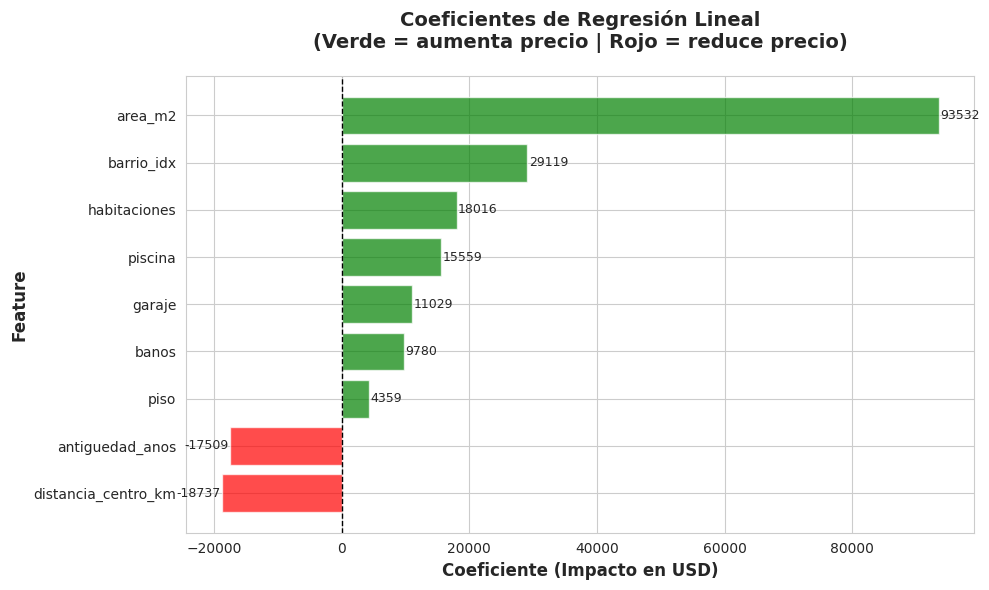


📊 COEFICIENTES (Interpretación):
area_m2                  : +93531.63  (aumenta el precio en $93531.63 por unidad)
habitaciones             : +18016.33  (aumenta el precio en $18016.33 por unidad)
banos                    : +9779.57  (aumenta el precio en $9779.57 por unidad)
antiguedad_anos          : -17508.99  (reduce el precio en $17508.99 por unidad)
distancia_centro_km      : -18736.94  (reduce el precio en $18736.94 por unidad)
piso                     : +4359.05  (aumenta el precio en $4359.05 por unidad)
garaje                   : +11029.15  (aumenta el precio en $11029.15 por unidad)
piscina                  : +15559.22  (aumenta el precio en $15559.22 por unidad)
barrio_idx               : +29118.85  (aumenta el precio en $29118.85 por unidad)

Intercepto: $337,707.08
   (Precio base cuando todas las variables normalizadas son 0)

✅ Visualización completada


In [0]:
# =============================================================================
# VISUALIZACIÓN DE COEFICIENTES
# =============================================================================

print("📊 VISUALIZACIÓN DE COEFICIENTES")
print("=" * 70)

# Crear DataFrame de coeficientes
coeficientes_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coeficiente': model.coefficients.toArray()
}).sort_values('Coeficiente', ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['red' if c < 0 else 'green' for c in coeficientes_df['Coeficiente']]
ax.barh(coeficientes_df['Feature'], coeficientes_df['Coeficiente'], color=colors, alpha=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coeficiente (Impacto en USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Coeficientes de Regresión Lineal\n(Verde = aumenta precio | Rojo = reduce precio)', 
             fontsize=14, fontweight='bold', pad=20)

for i, (feat, coef) in enumerate(zip(coeficientes_df['Feature'], coeficientes_df['Coeficiente'])):
    ax.text(coef + (200 if coef > 0 else -200), i, f'{coef:.0f}', 
            va='center', ha='left' if coef > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 COEFICIENTES (Interpretación):")
print("=" * 70)
for feat, coef in zip(feature_columns, model.coefficients):
    direccion = "aumenta" if coef > 0 else "reduce"
    print(f"{feat:25s}: {coef:+8.2f}  ({direccion} el precio en ${abs(coef):.2f} por unidad)")

print(f"\nIntercepto: ${model.intercept:,.2f}")
print("   (Precio base cuando todas las variables normalizadas son 0)\n")

print("✅ Visualización completada")

## ⚖️ Comparación: Regresión Lineal vs Árbol de Decisión

### Resultados esperados:

| Métrica | Regresión Lineal | Árbol de Decisión | Ganador |
|---------|-------------------|----------------------|---------|
| **RMSE** | ~$30,000-40,000 | ~$25,000-35,000 | 🏆 Árbol (capta no-linealidad) |
| **MAE** | ~$25,000-30,000 | ~$20,000-25,000 | 🏆 Árbol |
| **R²** | ~0.80-0.85 | ~0.85-0.90 | 🏆 Árbol |
| **Interpretabilidad** | Coeficientes directos | Feature importance | 🏆 Lineal (más claro) |
| **Velocidad** | Muy rápido | Rápido | 🏆 Lineal |
| **Overfitting** | Bajo riesgo | Riesgo medio | 🏆 Lineal |

### ¿Cuándo usar cada uno?

**Usa Regresión Lineal si:**
* Necesitas **máxima interpretabilidad** (explicar a stakeholders)
* Quieres **velocidad** (scoring de millones de propiedades)
* Tienes **pocos datos** (menos propenso a overfitting)
* La relación es **mayormente lineal**
* Necesitas **extrapolar** fuera del rango de entrenamiento

**Usa Árbol de Decisión si:**
* **Accuracy es prioritaria** sobre interpretabilidad
* Las relaciones son **no lineales** (ej: piscina solo vale en casas grandes)
* Hay **interacciones complejas** entre variables
* Tienes suficientes datos
* No necesitas extrapolar

### Conclusión:

* **Árbol de Decisión** suele ganar en accuracy por captar no-linealidad
* **Regresión Lineal** gana en interpretabilidad y velocidad
* **Ideal**: Usar ambos y comparar
* En producción: A veces se usa Lineal como **baseline rápido** y Árbol para **tasaciones críticas**

📊 VISUALIZACIÓN DE PREDICCIONES


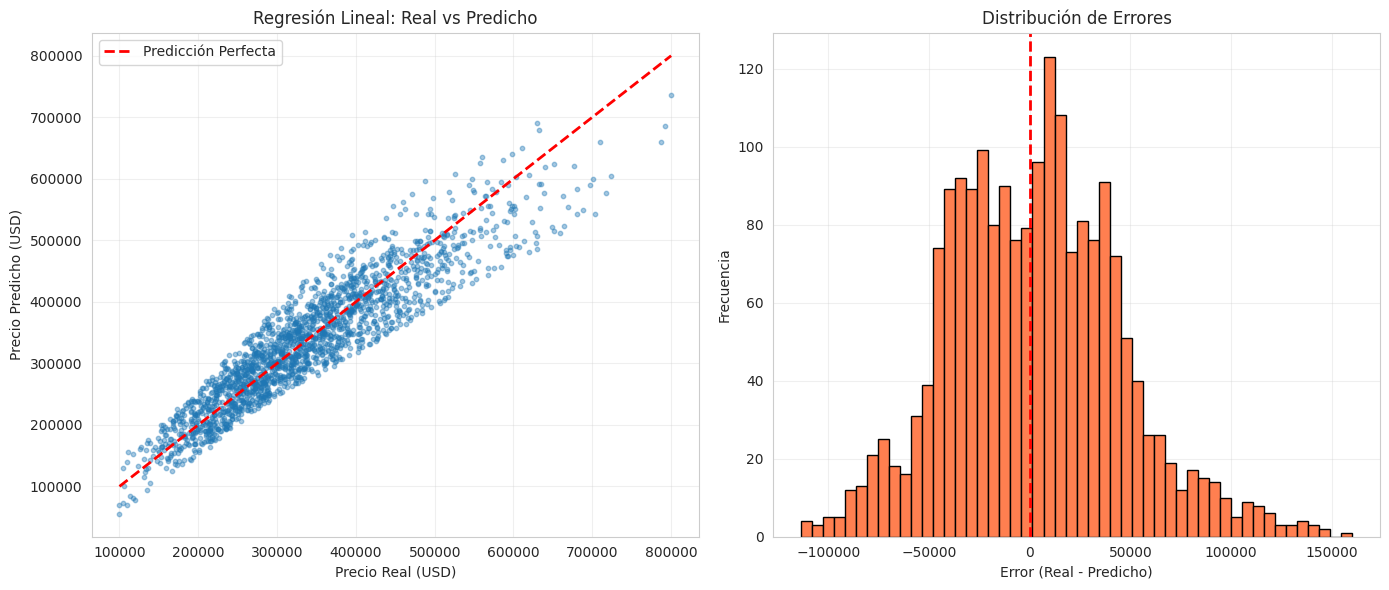

✅ Visualizaciones completadas


In [0]:
# =============================================================================
# VISUALIZACIÓN: PREDICCIONES vs REAL
# =============================================================================

print("📊 VISUALIZACIÓN DE PREDICCIONES")

predictions_pd = predictions.select("label", "prediction").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Real vs Predicho
axes[0].scatter(predictions_pd['label'], predictions_pd['prediction'], alpha=0.4, s=10)
axes[0].plot([predictions_pd['label'].min(), predictions_pd['label'].max()],
             [predictions_pd['label'].min(), predictions_pd['label'].max()],
             'r--', lw=2, label='Predicción Perfecta')
axes[0].set_xlabel('Precio Real (USD)')
axes[0].set_ylabel('Precio Predicho (USD)')
axes[0].set_title('Regresión Lineal: Real vs Predicho')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma de residuos
error = predictions_pd['label'] - predictions_pd['prediction']
axes[1].hist(error, bins=50, color='coral', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones completadas")

## 🎓 Conclusiones

### ✅ Lo que logramos:

1. Entrenamos un modelo de **Regresión Lineal Múltiple** para predecir precios
2. Aplicamos **normalización** (StandardScaler) - crítico para regresión lineal
3. Evaluamos con métricas de regresión (RMSE, MAE, R²)
4. Interpretamos **coeficientes** para entender el impacto de cada variable
5. Comparamos con Árbol de Decisión

### 💡 Insights clave:

* **Coeficientes positivos** (area_m2, baños, piscina, garaje): Aumentan precio
* **Coeficientes negativos** (antigüedad, distancia_centro): Reducen precio
* Magnitud del coeficiente indica **impacto en USD por unidad**
* Modelo asume **relaciones lineales** (limitación vs árboles)

### 🚀 Próximos pasos:

1. **Feature Engineering**: Crear interacciones (area × barrio) manualmente
2. **Probar regularización**: Lasso (L1) para selección automática de features
3. **Diagnóstico de supuestos**: Verificar linealidad, homocedasticidad, normalidad
4. **Comparar con modelos avanzados**: Random Forest, Gradient Boosting
5. **Ensemble**: Combinar Lineal + Árbol (promedio ponderado de predicciones)

---

**¡Felicitaciones!** Has completado Regresión Lineal Múltiple con PySpark ML. 🎉